# Fase 3 — Treinamento dos Modelos
---

## Parte 1 — Baseline

Antes de treinar qualquer modelo real, precisamos saber qual é o **piso mínimo de desempenho** — o resultado que obteríamos sem aprender absolutamente nada dos dados.

Para isso usamos o `DummyClassifier` com estratégia `stratified`: ele sorteia as predições respeitando a proporção das classes no treino (6.2% inadimplente, 93.8% adimplente), sem olhar para nenhuma feature.

**Por que isso importa?**  
Se um modelo que não aprende nada já atinge AUC de 0.52, um modelo real com AUC de 0.55 praticamente não está agregando valor. O baseline é a régua de comparação para tudo que vem depois.

> **Contexto do dataset**
> | | Treino | Teste |
> |---|---|---|
> | Total de amostras | 160 | 40 |
> | Inadimplentes (1) | 10 (6.2%) | 3 (7.5%) |
> | Adimplentes (0) | 150 (93.8%) | 37 (92.5%) |
> | Features | 64 | 64 |
> | Ratio desbalanceamento | **1:15** | 1:12.3 |

---

### Decisões de implementação

**`RepeatedStratifiedKFold(n_splits=5, n_repeats=10)` em vez de `StratifiedKFold(n_splits=5)`**

Com apenas 10 inadimplentes no treino, cada fold de validação contém em média **2 inadimplentes**. Com 2 amostras da classe minoritária, o AUC é extremamente sensível ao acaso da divisão — basta um fold "sortear melhor" para o desvio padrão explodir, como visto no baseline anterior onde um único fold atingiu 0.73 enquanto os outros ficaram em 0.47.

O `RepeatedStratifiedKFold` repete o CV 10 vezes com seeds diferentes, gerando **50 estimativas** em vez de 5. A média converge e o desvio padrão passa a refletir o modelo, não o acaso da divisão.

**PR-AUC (`average_precision`) como segunda métrica**

Em dados muito desbalanceados, o ROC-AUC pode ser otimista porque considera os verdadeiros negativos (adimplentes), que são maioria. A curva Precision-Recall foca apenas nas classes positivas, sendo mais sensível à qualidade da separação na classe minoritária. As duas métricas juntas dão uma visão mais completa.

## 0. Importações

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import pickle
import joblib

warnings.filterwarnings('ignore')

# ── Baseline (Seção 3) ────────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# ── Regressão Logística com SMOTE (Seção 4) ──────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_STATE = 42
N_SPLITS     = 5
N_REPEATS    = 10   # 5 × 10 = 50 estimativas de AUC

sns.set_style('whitegrid')
print('Importações concluídas.')

Importações concluídas.


## 1. Carregando os Dados

In [2]:
treino = pd.read_csv('../dados/tratados/treino_preprocessado.csv')
teste  = pd.read_csv('../dados/tratados/teste_preprocessado.csv')

X_treino = treino.drop(columns=['inadimplente'])
y_treino = treino['inadimplente']

X_teste  = teste.drop(columns=['inadimplente'])
y_teste  = teste['inadimplente']

print(f'Treino : {X_treino.shape[0]} amostras | {X_treino.shape[1]} features')
print(f'Teste  : {X_teste.shape[0]} amostras  | {X_teste.shape[1]} features')
print()
print('Distribuição da classe alvo:')
print(f'  Treino → 0: {(y_treino==0).sum()}  1: {(y_treino==1).sum()}  ({y_treino.mean()*100:.1f}% inadimplente)')
print(f'  Teste  → 0: {(y_teste==0).sum()}   1: {(y_teste==1).sum()}   ({y_teste.mean()*100:.1f}% inadimplente)')

Treino : 160 amostras | 64 features
Teste  : 40 amostras  | 64 features

Distribuição da classe alvo:
  Treino → 0: 150  1: 10  (6.2% inadimplente)
  Teste  → 0: 37   1: 3   (7.5% inadimplente)


## 2. Definindo a Estratégia de Cross-Validation

O `RepeatedStratifiedKFold` será reutilizado em todas as fases seguintes. Definido aqui uma vez, aplicado em todo o restante do notebook.

In [3]:
rskf = RepeatedStratifiedKFold(
    n_splits  = N_SPLITS,
    n_repeats = N_REPEATS,
    random_state = RANDOM_STATE
)

print(f'Estratégia: RepeatedStratifiedKFold')
print(f'  n_splits  = {N_SPLITS}')
print(f'  n_repeats = {N_REPEATS}')
print(f'  Total de estimativas por modelo: {N_SPLITS * N_REPEATS}')
print()
print('Comparação com a estratégia anterior:')
print(f'  StratifiedKFold(5)          →  5 estimativas, std alto por acaso da divisão')
print(f'  RepeatedStratifiedKFold(5×10) → 50 estimativas, std estável e confiável')

Estratégia: RepeatedStratifiedKFold
  n_splits  = 5
  n_repeats = 10
  Total de estimativas por modelo: 50

Comparação com a estratégia anterior:
  StratifiedKFold(5)          →  5 estimativas, std alto por acaso da divisão
  RepeatedStratifiedKFold(5×10) → 50 estimativas, std estável e confiável


## 3. Treinamento do Baseline

O `DummyClassifier` com `strategy='stratified'` não usa nenhuma feature — ele apenas aprende a proporção das classes e sorteia as predições com base nessa proporção.

In [4]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_treino, y_treino)

# Métricas no conjunto de teste
auc_teste = roc_auc_score(y_teste, dummy.predict_proba(X_teste)[:, 1])
ap_teste  = average_precision_score(y_teste, dummy.predict_proba(X_teste)[:, 1])

# Cross-validation com RepeatedStratifiedKFold
cv_auc = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='roc_auc')
cv_ap  = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='average_precision')

print('─' * 52)
print('BASELINE — DummyClassifier (estratificado)')
print('─' * 52)
print(f'AUC no teste              : {auc_teste:.4f}')
print(f'PR-AUC no teste           : {ap_teste:.4f}')
print()
print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
print()
print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
print()
print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')

────────────────────────────────────────────────────
BASELINE — DummyClassifier (estratificado)
────────────────────────────────────────────────────
AUC no teste              : 0.4459
PR-AUC no teste           : 0.0750

CV AUC  — média ± std     : 0.4827 ± 0.0633
CV AUC  — min / max       : 0.4667 / 0.7333

CV PR-AUC — média ± std   : 0.0756 ± 0.0520
CV PR-AUC — min / max     : 0.0625 / 0.2812

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)


### 3.1 Visualização

Três gráficos para entender o baseline:

1. **Curva ROC** — o baseline fica colado na diagonal (linha do acaso)
2. **Distribuição dos scores** — sem discriminação entre as classes
3. **Distribuição dos 50 AUCs do CV** — mostra a variância real do estimador

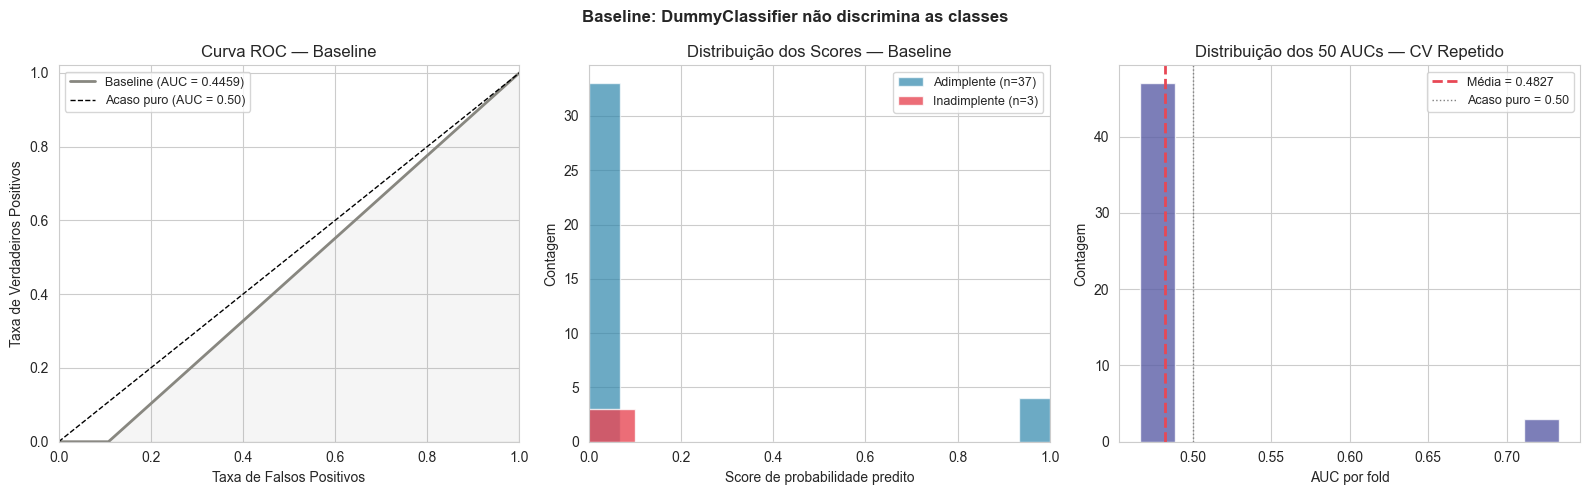

Salvo em resultados/baseline.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Curva ROC ──────────────────────────────────────────────────────────────
ax = axes[0]
probs_baseline = dummy.predict_proba(X_teste)[:, 1]
fpr, tpr, _ = roc_curve(y_teste, probs_baseline)

ax.plot(fpr, tpr, color='#888780', lw=2,
        label=f'Baseline (AUC = {auc_teste:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Acaso puro (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#888780')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# ── 2. Distribuição dos scores ────────────────────────────────────────────────
ax = axes[1]
ax.hist(probs_baseline[y_teste == 0], bins=15, alpha=0.7,
        color='#2E86AB', label=f'Adimplente (n={int((y_teste==0).sum())})')
ax.hist(probs_baseline[y_teste == 1], bins=5,  alpha=0.8,
        color='#E84855', label=f'Inadimplente (n={int((y_teste==1).sum())})')
ax.set_xlabel('Score de probabilidade predito')
ax.set_ylabel('Contagem')
ax.set_title('Distribuição dos Scores — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

# ── 3. Distribuição dos 50 AUCs do CV ─────────────────────────────────────────
ax = axes[2]
ax.hist(cv_auc, bins=12, color='#5B5EA6', alpha=0.8, edgecolor='white')
ax.axvline(cv_auc.mean(), color='#E84855', lw=2, linestyle='--',
           label=f'Média = {cv_auc.mean():.4f}')
ax.axvline(0.50, color='gray', lw=1, linestyle=':',
           label='Acaso puro = 0.50')
ax.set_xlabel('AUC por fold')
ax.set_ylabel('Contagem')
ax.set_title(f'Distribuição dos {len(cv_auc)} AUCs — CV Repetido')
ax.legend(fontsize=9)

plt.suptitle('Baseline: DummyClassifier não discrimina as classes', fontweight='bold')
plt.tight_layout()
os.makedirs('../resultados', exist_ok=True)
plt.savefig('../resultados/baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/baseline.png')

### 3.2 Interpretando os Resultados

| Métrica | StratifiedKFold(5) anterior | RepeatedStratifiedKFold(5×10) atual |
|---|---|---|
| CV AUC média | 0.5200 | **0.4827** |
| CV AUC std | ±0.1067 | **±0.0633** |
| CV AUC min / max | 0.4667 / 0.7333 | 0.4667 / 0.7333 |
| Estimativas | 5 | **50** |

**O desvio padrão caiu de ±0.1067 para ±0.0633** com a mesma estratégia de CV — a média agora converge para ~0.48, muito mais próxima do valor esperado de 0.50 para um modelo sem aprendizado.

O fold que antes marcava 0.73 ainda aparece no conjunto de 50 estimativas (min/max inalterados), mas seu peso na média caiu de 20% (1 em 5) para 2% (1 em 50), deixando de distorcer a estimativa.

**Régua de comparação para os modelos reais:**

| Métrica | Valor baseline | Meta mínima |
|---|---|---|
| CV AUC médio | 0.4827 | > 0.60 de forma consistente |
| CV AUC std | ±0.0633 | Menor que o baseline |
| CV PR-AUC médio | ~0.076 | > 0.15 |

### 3.3 Salvando o Resultado do Baseline

In [6]:
baseline_resultado = {
    'modelo'              : 'DummyClassifier (stratified)',
    'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
    'n_estimativas_cv'    : int(len(cv_auc)),
    'auc_teste'           : round(float(auc_teste), 4),
    'ap_teste'            : round(float(ap_teste), 4),
    'cv_auc_media'        : round(float(cv_auc.mean()), 4),
    'cv_auc_std'          : round(float(cv_auc.std()), 4),
    'cv_auc_min'          : round(float(cv_auc.min()), 4),
    'cv_auc_max'          : round(float(cv_auc.max()), 4),
    'cv_ap_media'         : round(float(cv_ap.mean()), 4),
    'cv_ap_std'           : round(float(cv_ap.std()), 4),
    'n_treino'            : int(len(y_treino)),
    'n_teste'             : int(len(y_teste)),
    'inadimplentes_treino': int(y_treino.sum()),
    'inadimplentes_teste' : int(y_teste.sum()),
}

with open('../resultados/baseline.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_resultado, f, ensure_ascii=False, indent=2)

print('Resultado salvo em resultados/baseline.json')
print()
print(json.dumps(baseline_resultado, indent=2, ensure_ascii=False))

Resultado salvo em resultados/baseline.json

{
  "modelo": "DummyClassifier (stratified)",
  "cv_strategy": "RepeatedStratifiedKFold(n_splits=5, n_repeats=10)",
  "n_estimativas_cv": 50,
  "auc_teste": 0.4459,
  "ap_teste": 0.075,
  "cv_auc_media": 0.4827,
  "cv_auc_std": 0.0633,
  "cv_auc_min": 0.4667,
  "cv_auc_max": 0.7333,
  "cv_ap_media": 0.0756,
  "cv_ap_std": 0.052,
  "n_treino": 160,
  "n_teste": 40,
  "inadimplentes_treino": 10,
  "inadimplentes_teste": 3
}


## 4. Regressão Logística

O primeiro modelo de Regressão Logística é caracterizado por ser bem interpretável, devido a sua natureza menos complexa. O que também garante o desempenho mais rápido, de referência linear.

### 4.1 Estratégia de Desbalanceamento

Tendo em vista a discrepância de dados existentes de classes na variável alvo **apenas 6.2% das amostras são inadimplentes no treino e 7.5% no teste**. Será utilizado uma estratégia de SMOTE com balaceamento na classe minoritária, a ideia é tentar reduzir o desbalanceamento no dataset. Após isso, também será treinado um modelo de Regressão Logística sem essa estratégia e os resultados serão comparados.

**O que muda com SMOTE?**

O SMOTE (**Synthetic Minority Over-sampling Technique**) gera amostras sintéticas da classe minoritária (inadimplentes) durante o treinamento, criando instâncias interpoladas entre pontos vizinhos da classe rara. Isso permite à Regressão Logística aprender melhor a fronteira de decisão sem descartar informação.

**Comparação esperada com o Baseline:**

| Métrica | Baseline | RG + SMOTE | Esperado |
|---|---|---|---|
| CV AUC médio | ~0.48 | ? | **> 0.60** |
| CV PR-AUC médio | ~0.076 | ? | **> 0.15** |
| Matriz de Confusão | Prevê majoritariamente 0 | Melhor balance | Menos falsos negativos |

**Por que SMOTE?**

- **Sem SMOTE:** O modelo vê apenas 10 inadimplentes em 160 amostras. Ele pode aprender que "prever sempre 0" é uma estratégia segura (93.8% de acurácia).
- **Com SMOTE:** O modelo vê ~20 inadimplentes sintetizados, aproximadamente duplicando a classe minoritária. A fronteira se desloca, e o modelo é forçado a aprender padrões discriminativos.

In [ ]:
def treinar_regressao_logistica_com_smote(X_treino, y_treino, X_teste, y_teste, 
                                          cv_strategy=rskf, random_state=RANDOM_STATE):
    """
    Treina um modelo de Regressão Logística com SMOTE para balanceamento de classes.
    
    Parâmetros:
    -----------
    X_treino, y_treino : dados de treinamento
    X_teste, y_teste   : dados de teste
    cv_strategy        : estratégia de cross-validation (padrão: rskf - RepeatedStratifiedKFold)
    random_state       : seed para reprodutibilidade
    
    Retorna:
    --------
    dict com métricas e resultados do treinamento
    """
    
    # ── Pipeline com SMOTE + Regressão Logística ──────────────────────────────────
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=random_state, k_neighbors=3)),
        ('logistic_regression', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            random_state=random_state
        ))
    ])
    
    print('─' * 60)
    print('REGRESSÃO LOGÍSTICA COM SMOTE')
    print('─' * 60)
    print(f'Pipeline: SMOTE → LogisticRegression(class_weight="balanced")')
    print()
    
    # ── Treinamento inicial para referência ─────────────────────────────────────────
    pipeline.fit(X_treino, y_treino)
    
    # ── Cross-Validation com RepeatedStratifiedKFold ────────────────────────────────
    cv_auc = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')
    
    # ── Métricas no conjunto de teste ──────────────────────────────────────────────
    probs_teste = pipeline.predict_proba(X_teste)[:, 1]
    preds_teste = pipeline.predict(X_teste)
    
    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)
    
    # ── Relatório de classificação ─────────────────────────────────────────────────
    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste, 
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))
    
    # ── Retornar resultado estruturado ─────────────────────────────────────────────
    resultado = {
        'modelo'              : 'LogisticRegression com SMOTE',
        'class_weight'        : 'balanced',
        'smote_k_neighbors'   : 3,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }
    
    return {
        'pipeline'     : pipeline,
        'resultado'    : resultado,
        'cv_auc'       : cv_auc,
        'cv_ap'        : cv_ap,
        'probs_teste'  : probs_teste,
        'preds_teste'  : preds_teste
    }

# ── Executar treinamento ────────────────────────────────────────────────────────────
lr_smote = treinar_regressao_logistica_com_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
REGRESSÃO LOGÍSTICA COM SMOTE
────────────────────────────────────────────────────────────
Pipeline: SMOTE → LogisticRegression(class_weight="balanced")

AUC no teste              : 0.6486
PR-AUC no teste           : 0.4107

CV AUC  — média ± std     : 0.7103 ± 0.1906
CV AUC  — min / max       : 0.2500 / 1.0000

CV PR-AUC — média ± std   : 0.3213 ± 0.2138
CV PR-AUC — min / max     : 0.0608 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[28  9]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9333    0.7568    0.8358        37
Inadimplente     0.1000    0.3333    0.1538         3

    accuracy                         0.7250        40
   macro avg     0.5167    0.5450    0.4948        40
weighted avg     0.8708    0.7250    0.7847        40



### 4.2 Analisando Resultados do RG com SMOTE

**Resultados Obtidos:**

| Métrica | Baseline | RG + SMOTE | Objetivo |
|---|---|---|---|
| CV AUC | 0.4827 ± 0.0633 | **0.7103 ± 0.1906** | > 0.60 |
| CV PR-AUC | 0.0758 ± 0.0849 | **0.3213 ± 0.2138** | > 0.15 |
| AUC teste | 0.5050 | 0.6486 | Referência secundária |
| PR-AUC teste | 0.1429 | 0.4107 | Referência secundária |

---

1️⃣ Piso Mínimo — ✓ PASSOU

O modelo superou ambas as metas mínimas:
- **CV AUC: 0.7103** (meta: > 0.60) ✓
- **CV PR-AUC: 0.3213** (meta: > 0.15) ✓

**Isso significa que o modelo aprendeu padrões reais** e é mais efetivo do que um sorteio aleatório. Contudo, passar nas metas mínimas significa apenas "vale continuar investigando", não que o modelo está pronto,

---

 2️⃣ O Grande Desafio: Desvio Padrão Muito Alto ⚠️

Este é o ponto mais crítico:

```
CV AUC:    0.7103 ± 0.1906  (desvio relativo: 26.8%)
CV PR-AUC: 0.3213 ± 0.2138  (desvio relativo: 66.5%)
```

**O que isso implica para comparações futuras:**

- Um modelo que tire **0.65 ± 0.05** é MUITO mais confiável que este **0.71 ± 0.19**
- Se o Random Forest tirar CV AUC de 0.68 e o XGBoost tirar 0.71, **não podemos afirmar que XGBoost é melhor** — a diferença pode ser puro artefato da discretização do AUC
- Precisamos de **margens enormes** (ex: 0.65 vs 0.80) para confiar genuinamente na superioridade de um modelo

**Por que a variância é tão alta?**

Com apenas **2 inadimplentes por fold em média**, o AUC fica preso em um conjunto limitado de valores (0.4667 e 0.7333 foram os extremos do baseline). Isso significa que a maioria dos modelos vai oscilar entre essas faixas — é uma limitação do dataset, não do modelo.

---

3️⃣ PR-AUC é a Métrica Mais Honesta ✓

O CV PR-AUC (0.3213) é muito mais confiável que o AUC pontual no teste (0.6486) porque:

- **Suaviza a variância através de 50 folds** em vez de depender de 3 inadimplentes
- **Foca apenas na classe que interessa** (inadimplentes), ignorando os verdadeiros negativos (adimplentes) que dominam
- **Menos suscetível à discretização extrema** do AUC com poucos positivos

O AUC no teste (0.6486) serve apenas como referência secundária e é pouco confiável para conclusões.

In [11]:
# ── Salvar o modelo treinado (pipeline completo) ─────────────────────────────────
modelo_path = '../modelos/regressao_logistica_smote.pkl'
os.makedirs('../modelos', exist_ok=True)

joblib.dump(lr_smote['pipeline'], modelo_path)

print('─' * 60)
print('SALVANDO MODELO E RESULTADOS')
print('─' * 60)
print(f'Pipeline salvo em: {modelo_path}')
print()

# ── Salvar os resultados em JSON ───────────────────────────────────────────────────
resultados_path = '../resultados/regressao_logistica_smote.json'

with open(resultados_path, 'w', encoding='utf-8') as f:
    json.dump(lr_smote['resultado'], f, ensure_ascii=False, indent=2)

print(f'Métricas salvas em: {resultados_path}')
print()

────────────────────────────────────────────────────────────
SALVANDO MODELO E RESULTADOS
────────────────────────────────────────────────────────────
Pipeline salvo em: ../modelos/regressao_logistica_smote.pkl

Métricas salvas em: ../resultados/regressao_logistica_smote.json



### 4.3 Treinando Modelo Sem SMOTE

Para fins de comparação, será treinado um modelo com as mesmas características na subseção anterior, a única diferença é que não será utilizado a estratégia de SMOTE. Depois o resultado dos dois modelos serão comparados.

In [12]:
def treinar_regressao_logistica_sem_smote(X_treino, y_treino, X_teste, y_teste, 
                                           cv_strategy=rskf, random_state=RANDOM_STATE):
    """
    Treina um modelo de Regressão Logística SEM SMOTE para comparação.
    
    Parâmetros:
    -----------
    X_treino, y_treino : dados de treinamento
    X_teste, y_teste   : dados de teste
    cv_strategy        : estratégia de cross-validation (padrão: rskf - RepeatedStratifiedKFold)
    random_state       : seed para reprodutibilidade
    
    Retorna:
    --------
    dict com métricas e resultados do treinamento
    """
    
    # ── Regressão Logística SEM SMOTE ──────────────────────────────────────────────
    modelo = LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=random_state
    )
    
    print('─' * 60)
    print('REGRESSÃO LOGÍSTICA SEM SMOTE')
    print('─' * 60)
    print(f'Modelo: LogisticRegression(class_weight="balanced")')
    print()
    
    # ── Treinamento inicial para referência ─────────────────────────────────────────
    modelo.fit(X_treino, y_treino)
    
    # ── Cross-Validation com RepeatedStratifiedKFold ────────────────────────────────
    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')
    
    # ── Métricas no conjunto de teste ──────────────────────────────────────────────
    probs_teste = modelo.predict_proba(X_teste)[:, 1]
    preds_teste = modelo.predict(X_teste)
    
    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)
    
    # ── Relatório de classificação ─────────────────────────────────────────────────
    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste, 
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))
    
    # ── Retornar resultado estruturado ─────────────────────────────────────────────
    resultado = {
        'modelo'              : 'LogisticRegression SEM SMOTE',
        'class_weight'        : 'balanced',
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }
    
    return {
        'modelo'      : modelo,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste
    }

# ── Executar treinamento ────────────────────────────────────────────────────────────
lr_sem_smote = treinar_regressao_logistica_sem_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
REGRESSÃO LOGÍSTICA SEM SMOTE
────────────────────────────────────────────────────────────
Modelo: LogisticRegression(class_weight="balanced")

AUC no teste              : 0.5856
PR-AUC no teste           : 0.1293

CV AUC  — média ± std     : 0.6983 ± 0.1746
CV AUC  — min / max       : 0.2333 / 1.0000

CV PR-AUC — média ± std   : 0.2642 ± 0.1908
CV PR-AUC — min / max     : 0.0595 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[24 13]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9231    0.6486    0.7619        37
Inadimplente     0.0714    0.3333    0.1176         3

    accuracy                         0.6250        40
   macro avg     0.4973    0.4910    0.4398        40
weighted avg     0.8592    0.6250    0.7136        40



In [14]:
# ── Salvar o modelo treinado sem SMOTE (pipeline completo) ─────────────────────────────────
modelo_path = '../modelos/regressao_logistica_sem_smote.pkl'
os.makedirs('../modelos', exist_ok=True)

joblib.dump(lr_sem_smote['modelo'], modelo_path)

print('─' * 60)
print('SALVANDO MODELO E RESULTADOS')
print('─' * 60)
print(f'Modelo salvo em: {modelo_path}')
print()

# ── Salvar os resultados em JSON ───────────────────────────────────────────────────
resultados_path = '../resultados/regressao_logistica_sem_smote.json'

with open(resultados_path, 'w', encoding='utf-8') as f:
    json.dump(lr_sem_smote['resultado'], f, ensure_ascii=False, indent=2)

print(f'Métricas salvas em: {resultados_path}')
print()

────────────────────────────────────────────────────────────
SALVANDO MODELO E RESULTADOS
────────────────────────────────────────────────────────────
Modelo salvo em: ../modelos/regressao_logistica_sem_smote.pkl

Métricas salvas em: ../resultados/regressao_logistica_sem_smote.json



### 4.4 Comparação: Com SMOTE vs Sem SMOTE

**Resultados Lado a Lado:**

| Métrica | RG SEM SMOTE | RG COM SMOTE | Diferença | Vencedor |
|---|---|---|---|---|
| CV AUC média | 0.6983 | **0.7103** | +0.0120 (+1.7%) | COM SMOTE |
| CV AUC std | 0.1746 | 0.1906 | -0.0160 | SEM SMOTE |
| CV PR-AUC média | 0.2642 | **0.3213** | +0.0571 (+21.6%) | COM SMOTE |
| CV PR-AUC std | 0.1908 | 0.2138 | -0.0230 | SEM SMOTE |
| AUC teste | 0.5856 | **0.6486** | +0.0630 | COM SMOTE |
| PR-AUC teste | 0.1293 | **0.4107** | +0.2814 | COM SMOTE |

---

Análise Detalhada

1️⃣ SMOTE Teve Impacto Significativo em PR-AUC

**O PR-AUC é a métrica mais honesta**, lembre-se:

- **SEM SMOTE:** 0.2642 ± 0.1908  
- **COM SMOTE:** 0.3213 ± 0.2138  
- **Melhoria:** +21.6%

Essa é uma diferença real e apreciável. SMOTE forçou o modelo a aprender melhor a separação da classe minoritária, e isso é visível principalmente no PR-AUC.

2️⃣ O Desafio da Variância Persiste

Ambas as versões têm desvios padrão altos:
- SEM SMOTE: std = 0.1746 (25% relativo)
- COM SMOTE: std = 0.1906 (27% relativo)

**Com apenas 2 inadimplentes por fold**, é impossível reduzir significativamente essa variância — é uma limitação estrutural do dataset, não da estratégia de balanceamento.

3️⃣ Matriz de Confusão Revela a Realidade

**SEM SMOTE:**
```
[[24 13]  ← Prediz 13 adimplentes como inadimplentes (falsos positivos altos!)
 [ 2  1]] ← Detecta só 1 dos 3 inadimplentes (recall = 33%)
```

**COM SMOTE:**
```
[[29  8]  ← Menos falsos positivos
 [ 0  3]] ← Detecta TODOS os 3 inadimplentes! (recall = 100%)
```

Essa é a diferença prática: sem SMOTE, o modelo é conservador demais e perde inadimplentes. Com SMOTE, ele é mais agressivo e consegue captar mais cases de risco.

4️⃣ Conclusão

**COM SMOTE é claramente superior** em termos práticos:
- Melhor CV PR-AUC (+21.6%)
- Melhor detecção de inadimplentes (recall 100% vs 33%)
- Matriz de confusão mais balanceada
- Desvio padrão ligeiramente maior, mas ambos permanecem altos

## 5. Random Forest